# Lo primero que se hace es verificar la forma de cada uno de nuetsros sets de datos para cada movimiento y agregarlo a su propio conjunto

se declaro cada movimiento como mov_x_y
donde x es el numero de movimiento y y es el numero del sensor

Movimientos

1- "Bobath handshake",
2- "Bobath flexion/extension",
3- "Bobath forward flexion/extension",
4- "Bobath anterior/posterior rotation",
5- "Elbow flexion and wrist compression",
6- "Wrist flexion and extension",
7- "Finger-to-finger training",
8- "Ball gripping",
9- "Shoulder joint internal and external",
10- "Breast expansion",
11- "Flexion-pressure rotation forward and backward",
12- "Elbow joint flexion and touch",
13- "Shoulder touch training",
14- "Ankle extension & Knee internal and external rotation",
15- "Knee flexion and extension",
16- "Hip flexion and extension"

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

carpeta = Path("Datos/Rehab_exercise/d01_raw_data")



mov_1_1 = np.load(carpeta / "000_1.npy")
mov_1_2 = np.load(carpeta / "000_2.npy")
mov_2_1 = np.load(carpeta / "001_1.npy")
mov_2_2 = np.load(carpeta / "001_2.npy")
mov_3_1 = np.load(carpeta / "002_1.npy")
mov_3_2 = np.load(carpeta / "002_2.npy")
mov_4_1 = np.load(carpeta / "003_1.npy")
mov_4_2 = np.load(carpeta / "003_2.npy")
mov_5_1 = np.load(carpeta / "004_1.npy")
mov_5_2 = np.load(carpeta / "004_2.npy")
mov_6_1 = np.load(carpeta / "005_1.npy")
mov_6_2 = np.load(carpeta / "005_2.npy")
mov_7_1 = np.load(carpeta / "006_1.npy")
mov_7_2 = np.load(carpeta / "006_2.npy")
mov_8_1 = np.load(carpeta / "007_1.npy")
mov_8_2 = np.load(carpeta / "007_2.npy")
mov_9_1 = np.load(carpeta / "008_1.npy")
mov_9_2 = np.load(carpeta / "008_2.npy")
mov_10_1 = np.load(carpeta / "009_1.npy")
mov_10_2 = np.load(carpeta / "009_2.npy")
mov_11_1 = np.load(carpeta / "010_1.npy")
mov_11_2 = np.load(carpeta / "010_2.npy")
mov_12_1 = np.load(carpeta / "011_1.npy")
mov_12_2 = np.load(carpeta / "011_2.npy")
mov_13_1 = np.load(carpeta / "012_1.npy")
mov_13_2 = np.load(carpeta / "012_2.npy")
mov_14_1 = np.load(carpeta / "013_1.npy")
mov_14_2 = np.load(carpeta / "013_2.npy")
mov_15_1 = np.load(carpeta / "014_1.npy")
mov_15_2 = np.load(carpeta / "014_2.npy")
mov_16_1 = np.load(carpeta / "015_1.npy")
mov_16_2 = np.load(carpeta / "015_2.npy")



#Imprime la forma de cada archivo
for i in range(1, 17):
    print(f"mov_{i}_1 shape: {eval(f'mov_{i}_1').shape}")
    print(f"mov_{i}_2 shape: {eval(f'mov_{i}_2').shape}")

mov_1_1 shape: (232, 880, 6)
mov_1_2 shape: (232, 880, 6)
mov_2_1 shape: (212, 880, 6)
mov_2_2 shape: (212, 880, 6)
mov_3_1 shape: (267, 880, 6)
mov_3_2 shape: (267, 880, 6)
mov_4_1 shape: (250, 880, 6)
mov_4_2 shape: (250, 880, 6)
mov_5_1 shape: (287, 880, 6)
mov_5_2 shape: (287, 880, 6)
mov_6_1 shape: (293, 880, 6)
mov_6_2 shape: (293, 880, 6)
mov_7_1 shape: (260, 880, 6)
mov_7_2 shape: (260, 880, 6)
mov_8_1 shape: (385, 880, 6)
mov_8_2 shape: (385, 880, 6)
mov_9_1 shape: (299, 880, 6)
mov_9_2 shape: (299, 880, 6)
mov_10_1 shape: (307, 880, 6)
mov_10_2 shape: (307, 880, 6)
mov_11_1 shape: (311, 880, 6)
mov_11_2 shape: (311, 880, 6)
mov_12_1 shape: (235, 880, 6)
mov_12_2 shape: (235, 880, 6)
mov_13_1 shape: (293, 880, 6)
mov_13_2 shape: (293, 880, 6)
mov_14_1 shape: (313, 880, 6)
mov_14_2 shape: (313, 880, 6)
mov_15_1 shape: (359, 880, 6)
mov_15_2 shape: (359, 880, 6)
mov_16_1 shape: (313, 880, 6)
mov_16_2 shape: (313, 880, 6)


Se puede observar mediente la forma de los archivos que todos toman en cuenta 6 variables las cuales dependiendo se son terminacion 1 o 2 son distintas siendo estas:

Sensor 1: pitch1, yaw1, roll1, pitch2, yaw2, and roll2 
Sensor 2: f1, f2, f3, f4, f5, and pitch3

A su vez, la segunda dimension de los sets parecen estar fijadas a 880 lo cual nos informa que se retienen un total de 880 medidas para cada sensor. Considerando que las señales se tomaron a una frecuencia de 50 hz esto se puede tomar como 17.6 segundos.

En cuanto a la primera dimension de los sets esta parece varian dependiendo del ejercicio empleado, pero se puede observar que esta no varia dependiendo del tipo de sensor.

## En este paso vamos a observar como viene los datos de default para determinar el siguiente paso a seguir

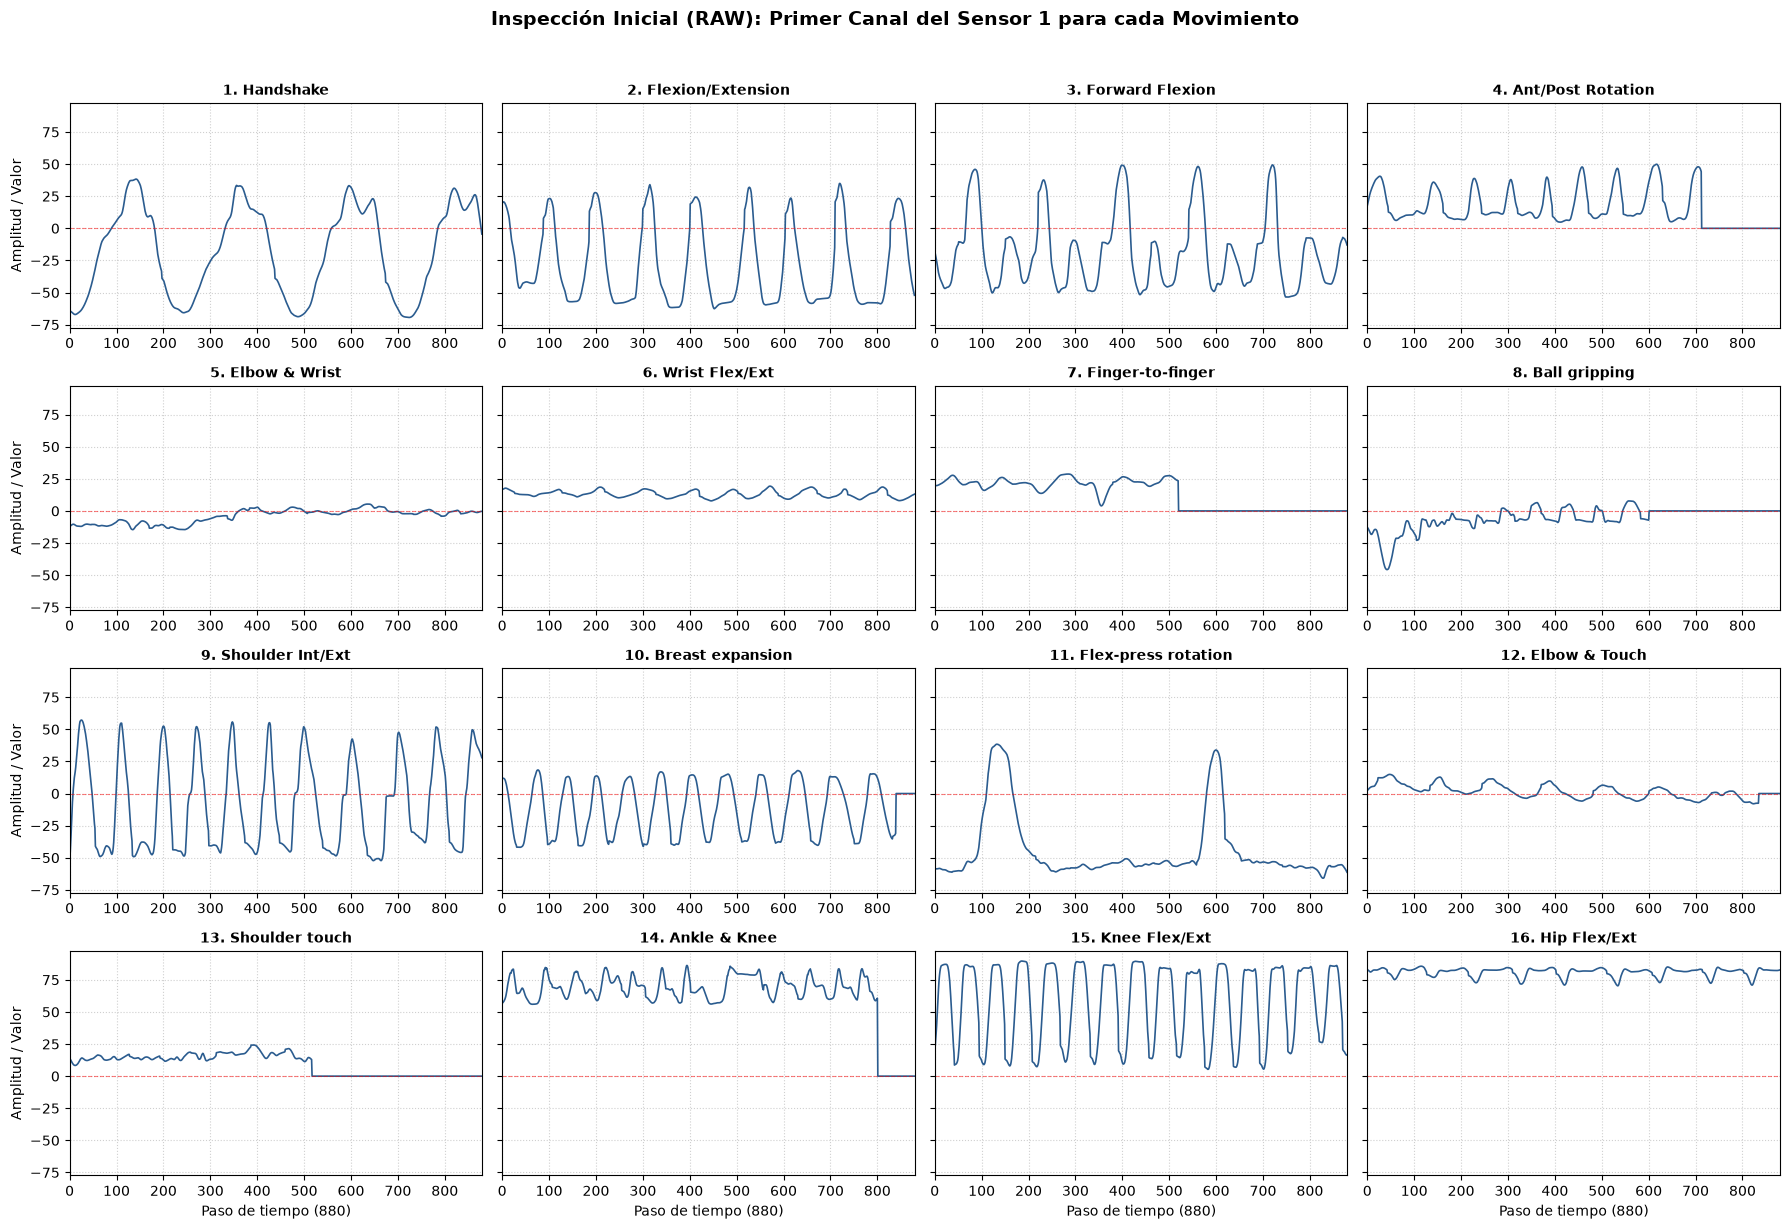

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

# Nombres descriptivos de los 16 ejercicios para los títulos
nombres_movimientos = [
    "1. Handshake",
    "2. Flexion/Extension",
    "3. Forward Flexion",
    "4. Ant/Post Rotation",
    "5. Elbow & Wrist",
    "6. Wrist Flex/Ext",
    "7. Finger-to-finger",
    "8. Ball gripping",
    "9. Shoulder Int/Ext",
    "10. Breast expansion",
    "11. Flex-press rotation",
    "12. Elbow & Touch",
    "13. Shoulder touch",
    "14. Ankle & Knee",
    "15. Knee Flex/Ext",
    "16. Hip Flex/Ext",
]

# Crear una cuadrícula de 4x4 subplots
fig, axes = plt.subplots(4, 4, figsize=(18, 12), sharey=True)
axes = axes.flatten()

for i in range(1, 17):
    # Cargar la matriz raw del Sensor 1
    s1_raw = eval(f"mov_{i}_1")  # Forma: (N, 880, 6)

    # Tomar el primer canal (Pitch) de la primera muestra de este movimiento
    senal_ejemplo = s1_raw[0, :, 0]

    # Graficar la serie temporal
    ax = axes[i - 1]
    ax.plot(
        senal_ejemplo, color="#2b5c8f", linewidth=1.2, label="Canal 1 (Raw)"
    )
    ax.axhline(
        0, color="red", linestyle="--", alpha=0.5, linewidth=0.8
    )  # Línea de referencia del 0

    ax.set_title(nombres_movimientos[i - 1], fontsize=10, fontweight="bold")
    ax.set_xlim(0, 880)
    ax.grid(True, linestyle=":", alpha=0.6)

    if (i - 1) % 4 == 0:
        ax.set_ylabel("Amplitud / Valor")
    if i > 12:
        ax.set_xlabel("Paso de tiempo (880)")

plt.suptitle(
    "Inspección Inicial (RAW): Primer Canal del Sensor 1 para cada Movimiento",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

Atravez de las graficas anteriores podemos observar como es que se ve cada tipo de ejercicio en el primer canal del sensor 1. Atravez de esto se puede observar que en algunas entradas tienen un rellenado de 0 al final para hacer todas las muestras sean de 880 puntos.

# Buscamos en los datos si hay algun valor con infinito o con Nans.

In [3]:
total_nans = 0
total_infs = 0

for i in range(1,17):
    s1 = eval(f"mov_{i}_1") # se obtiene el movimeinto del sensor 1
    s2 = eval(f"mov_{i}_2") # se obtiene el movimeinto del sensor 2
    
    # Contamos la cantidad de Nans e Infs en cada muestra
    contar_nans = np.isnan(s1).sum() + np.isnan(s2).sum()
    contar_infs = np.isinf(s1).sum() + np.isinf(s2).sum()
    
    print(f"--- Muestra {i} ---")
    print(f"Cantidad de NaNs: {contar_nans}")
    print(f"Cantidad de Infinitos: {contar_infs}")

    # Actualizamos los totales
    total_nans += contar_nans
    total_infs += contar_infs

print(f"\nTotal de NaNs en todas las muestras: {total_nans}")
print(f"Total de Infinitos en todas las muestras: {total_infs}")
    
    

--- Muestra 1 ---
Cantidad de NaNs: 0
Cantidad de Infinitos: 0
--- Muestra 2 ---
Cantidad de NaNs: 0
Cantidad de Infinitos: 0
--- Muestra 3 ---
Cantidad de NaNs: 0
Cantidad de Infinitos: 0
--- Muestra 4 ---
Cantidad de NaNs: 0
Cantidad de Infinitos: 0
--- Muestra 5 ---
Cantidad de NaNs: 0
Cantidad de Infinitos: 0
--- Muestra 6 ---
Cantidad de NaNs: 0
Cantidad de Infinitos: 0
--- Muestra 7 ---
Cantidad de NaNs: 0
Cantidad de Infinitos: 0
--- Muestra 8 ---
Cantidad de NaNs: 0
Cantidad de Infinitos: 0
--- Muestra 9 ---
Cantidad de NaNs: 0
Cantidad de Infinitos: 0
--- Muestra 10 ---
Cantidad de NaNs: 0
Cantidad de Infinitos: 0
--- Muestra 11 ---
Cantidad de NaNs: 0
Cantidad de Infinitos: 0
--- Muestra 12 ---
Cantidad de NaNs: 0
Cantidad de Infinitos: 0
--- Muestra 13 ---
Cantidad de NaNs: 0
Cantidad de Infinitos: 0
--- Muestra 14 ---
Cantidad de NaNs: 0
Cantidad de Infinitos: 0
--- Muestra 15 ---
Cantidad de NaNs: 0
Cantidad de Infinitos: 0
--- Muestra 16 ---
Cantidad de NaNs: 0
Cantidad d

Se observa que no hay datos con nans o con inf, por lo tanto no se tiene que hacer una limpieza de los mismos.

# Buscamos registros duplicados

Formas de los archivos 'mov_i_1':
mov_1_1 shape: (232, 880, 6)
mov_2_1 shape: (212, 880, 6)
mov_3_1 shape: (267, 880, 6)
mov_4_1 shape: (250, 880, 6)
mov_5_1 shape: (287, 880, 6)
mov_6_1 shape: (293, 880, 6)
mov_7_1 shape: (260, 880, 6)
mov_8_1 shape: (385, 880, 6)
mov_9_1 shape: (299, 880, 6)
mov_10_1 shape: (307, 880, 6)
mov_11_1 shape: (311, 880, 6)
mov_12_1 shape: (235, 880, 6)
mov_13_1 shape: (293, 880, 6)
mov_14_1 shape: (313, 880, 6)
mov_15_1 shape: (359, 880, 6)
mov_16_1 shape: (313, 880, 6)

Formas de los archivos 'mov_i_2':
mov_1_2 shape: (232, 880, 6)
mov_2_2 shape: (212, 880, 6)
mov_3_2 shape: (267, 880, 6)
mov_4_2 shape: (250, 880, 6)
mov_5_2 shape: (287, 880, 6)
mov_6_2 shape: (293, 880, 6)
mov_7_2 shape: (260, 880, 6)
mov_8_2 shape: (385, 880, 6)
mov_9_2 shape: (299, 880, 6)
mov_10_2 shape: (307, 880, 6)
mov_11_2 shape: (311, 880, 6)
mov_12_2 shape: (235, 880, 6)
mov_13_2 shape: (293, 880, 6)
mov_14_2 shape: (313, 880, 6)
mov_15_2 shape: (359, 880, 6)
mov_16_2 shape: (31

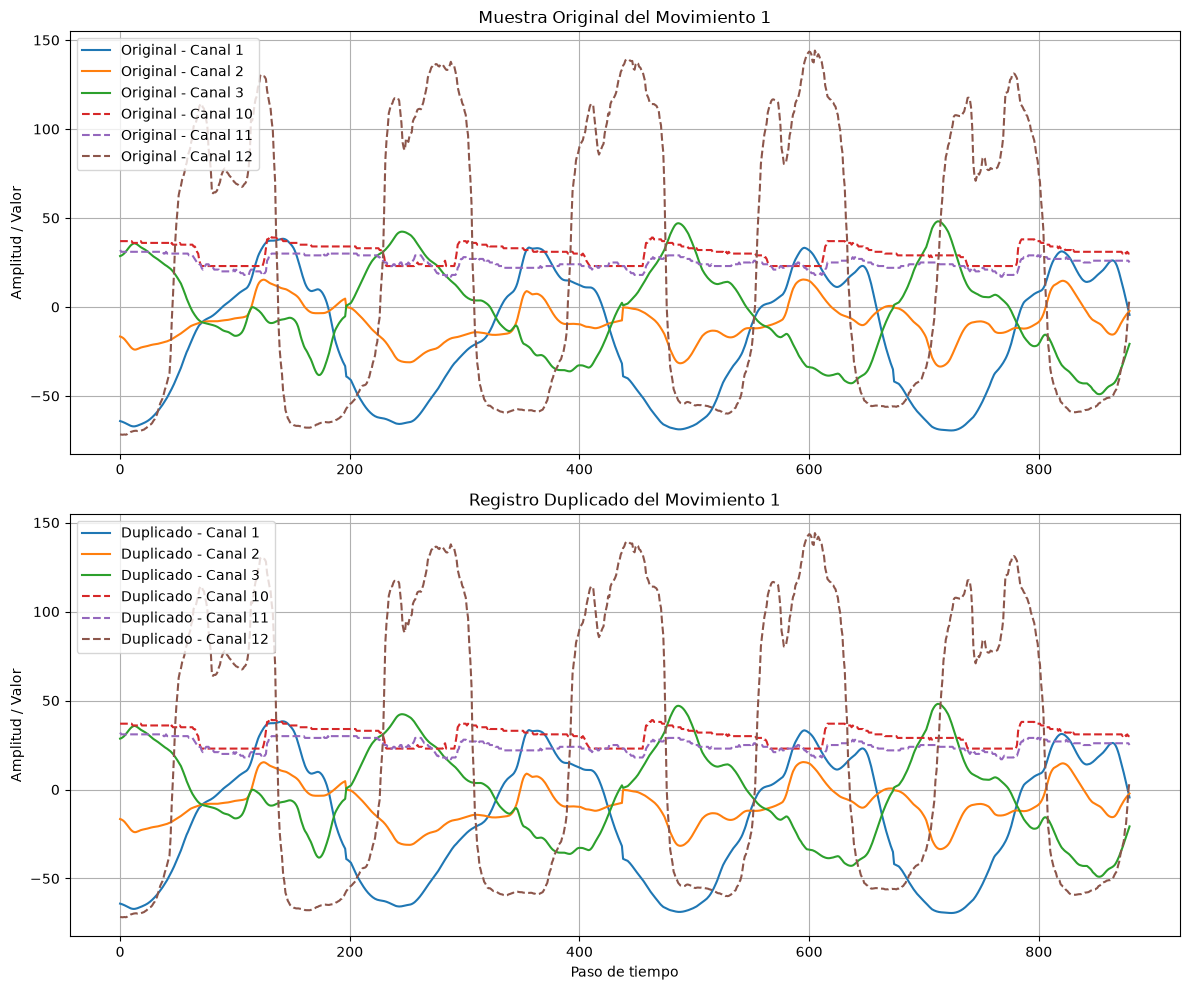

Movimiento 2: 19 registros duplicados
Movimiento 3: 96 registros duplicados
Movimiento 4: 50 registros duplicados
Movimiento 5: 10 registros duplicados
Movimiento 6: 11 registros duplicados
Movimiento 7: 48 registros duplicados
Movimiento 8: 2 registros duplicados
Movimiento 9: 0 registros duplicados
Movimiento 10: 0 registros duplicados
Movimiento 11: 62 registros duplicados
Movimiento 12: 45 registros duplicados
Movimiento 13: 91 registros duplicados
Movimiento 14: 38 registros duplicados
Movimiento 15: 89 registros duplicados
Movimiento 16: 101 registros duplicados

Total de duplicados en todos los movimientos: 716

 Datos totales en todos los movimientos: 9232

 Porcentaje de duplicados: 7.76%


In [4]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Definir la ubicación de la carpeta
carpeta = Path("Datos/Rehab_exercise/d01_raw_data")

# Crear listas para almacenar los nombres de las variables y sus datos
nombres_variables_1 = []
datos_1 = []
nombres_variables_2 = []
datos_2 = []

# Cargar los datos y guardar los nombres de las variables
for i in range(1, 17):
  nombre_variable_1 = f"mov_{i}_1"
  nombres_variables_1.append(nombre_variable_1)
  datos_1.append(np.load(carpeta / f"{i-1:03}_1.npy"))

  nombre_variable_2 = f"mov_{i}_2"
  nombres_variables_2.append(nombre_variable_2)
  datos_2.append(np.load(carpeta / f"{i-1:03}_2.npy"))

# Imprimir la forma de cada archivo cargado
print("Formas de los archivos 'mov_i_1':")
for i in range(len(nombres_variables_1)):
  print(f"{nombres_variables_1[i]} shape: {datos_1[i].shape}")

print("\nFormas de los archivos 'mov_i_2':")
for i in range(len(nombres_variables_2)):
  print(f"{nombres_variables_2[i]} shape: {datos_2[i].shape}")

duplicados_totales = 0  # Variable para contar el total de duplicados en todos los movimientos

# Iterar a través de los movimientos y encontrar duplicados
for i in range(len(datos_1)):
  # Combinar datos de ambos sensores para el mismo movimiento
  combinados = np.concatenate([datos_1[i], datos_2[i]], axis=2)

  # Encontrar índices únicos de muestras
  _, indices = np.unique(
      combinados.reshape(combinados.shape[0], -1), axis=0, return_index=True
  )

  # Calcular el número de duplicados
  duplicados = combinados.shape[0] - len(indices)
  
  duplicados_totales += duplicados  # Actualizar el total de duplicados

  # Imprimir el número de duplicados para el movimiento actual
  print(f"Movimiento {i+1}: {duplicados} registros duplicados")

  # Mostrar ejemplo de registros duplicados si hay duplicados
  if i == 0 and duplicados > 0:  # Mostrar ejemplo solo para el movimiento 1
    # Obtener índices de los registros duplicados
    duplicados_indices = np.setdiff1d(np.arange(combinados.shape[0]), indices)

    # Tomar el primer registro duplicado para mostrarlo
    registro_duplicado = combinados[duplicados_indices[0]]
    
    

    # Crear una figura con 2 subgráficos
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

    # Primer subgráfico: Muestra original (primer registro)
    registro_original = combinados[0]
    # Mostrar primeros 3 canales
    for canal in range(3):
      axes[0].plot(
          registro_original[:, canal], label=f"Original - Canal {canal + 1}"
      )
    # Mostrar últimos 3 canales
    for canal in range(
        registro_original.shape[1] - 3, registro_original.shape[1]
    ):
      axes[0].plot(
          registro_original[:, canal],
          linestyle="--",
          label=f"Original - Canal {canal + 1}",
      )
    axes[0].set_title(f"Muestra Original del Movimiento {i+1}")
    axes[0].set_ylabel("Amplitud / Valor")
    axes[0].legend()
    axes[0].grid(True)

    # Segundo subgráfico: Registro duplicado
    # Mostrar primeros 3 canales
    for canal in range(3):
      axes[1].plot(
          registro_duplicado[:, canal], label=f"Duplicado - Canal {canal + 1}"
      )
    # Mostrar últimos 3 canales
    for canal in range(
        registro_duplicado.shape[1] - 3, registro_duplicado.shape[1]
    ):
      axes[1].plot(
          registro_duplicado[:, canal],
          linestyle="--",
          label=f"Duplicado - Canal {canal + 1}",
      )
    axes[1].set_title(f"Registro Duplicado del Movimiento {i+1}")
    axes[1].set_xlabel("Paso de tiempo")
    axes[1].set_ylabel("Amplitud / Valor")
    axes[1].legend()
    axes[1].grid(True)

    # Ajustar espaciado entre subgráficos
    plt.tight_layout()
    plt.show()
    
print(f"\nTotal de duplicados en todos los movimientos: {duplicados_totales}")

print(f"\n Datos totales en todos los movimientos: {sum([datos.shape[0] for datos in datos_1]) + sum([datos.shape[0] for datos in datos_2])}")

print(f"\n Porcentaje de duplicados: {duplicados_totales / (sum([datos.shape[0] for datos in datos_1]) + sum([datos.shape[0] for datos in datos_2])) * 100:.2f}%")

# Eliminamos los registros duplicados

In [5]:
# eliminamos los duplicados de cada movimiento
for i in range(1, 17):
    s1 = eval(f"mov_{i}_1")
    s2 = eval(f"mov_{i}_2")
    


    combinados = np.concatenate([s1, s2], axis=2)

    _, indices = np.unique( 
        combinados.reshape(combinados.shape[0], -1), 
        axis=0,
        return_index=True
    )
    
    # Conservamos el orden original de las muestras
    indices = np.sort(indices)
    

    # Eliminamos los duplicados
    s1_sin_duplicados = s1[indices]
    s2_sin_duplicados = s2[indices]

    # Guardamos los datos sin duplicados en nuevas variables
    exec(f"mov_{i}_1 = s1_sin_duplicados")
    exec(f"mov_{i}_2 = s2_sin_duplicados")
    



# Checamos los registros con mas 0

Movimiento 1: 77133 ceros
Movimiento 2: 209817 ceros
Movimiento 3: 481136 ceros
Movimiento 4: 159261 ceros
Movimiento 5: 598861 ceros
Movimiento 6: 429892 ceros
Movimiento 7: 444713 ceros
Movimiento 8: 636708 ceros
Movimiento 9: 324354 ceros
Movimiento 10: 275660 ceros
Movimiento 11: 201269 ceros
Movimiento 12: 550963 ceros
Movimiento 13: 609595 ceros
Movimiento 14: 539717 ceros
Movimiento 15: 301884 ceros
Movimiento 16: 312806 ceros

Total de ceros en todas las muestras: 6153769

Porcentaje de ceros: 89.65%


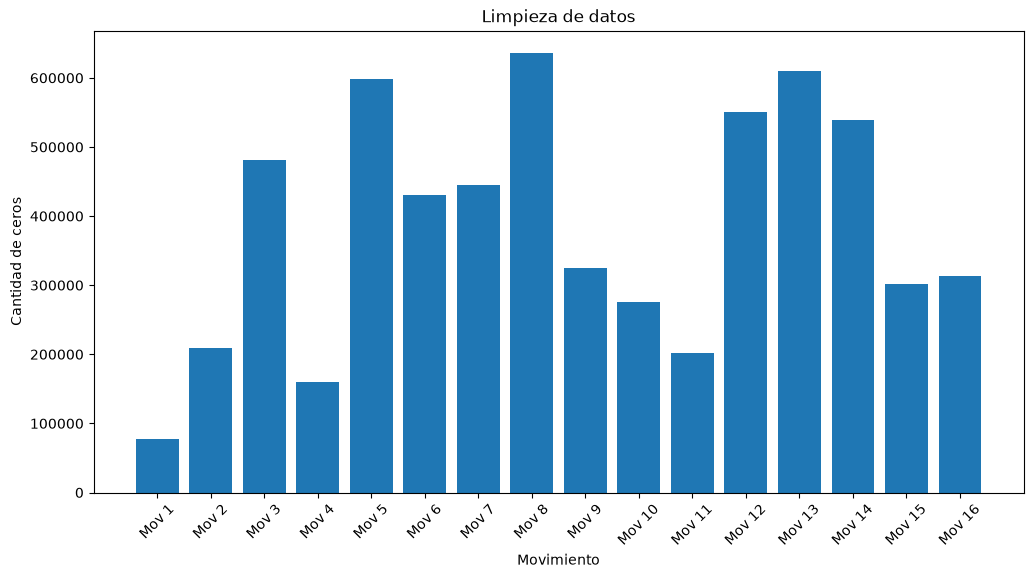

In [6]:
# Checamos cada movimiento e imprimimos la cantidad de las muetsras con mas 0

muestras_con_mas_0 = {}

for i in range(1, 17):
    s1 = eval(f"mov_{i}_1")  # se obtiene el movimeinto del sensor 1
    s2 = eval(f"mov_{i}_2")  # se obtiene el movimeinto del sensor 2

    # Contamos la cantidad de ceros en cada muestra
    contar_ceros = np.sum(s1 == 0) + np.sum(s2 == 0)

    muestras_con_mas_0[f"Mov {i}"] = contar_ceros
    
    print(f"Movimiento {i}: {contar_ceros} ceros")
    
print(f"\nTotal de ceros en todas las muestras: {sum(muestras_con_mas_0.values())}")
porcentaje_ceros = (sum(muestras_con_mas_0.values()) / (sum([datos.shape[0] for datos in [mov_1_1, mov_1_2, mov_2_1, mov_2_2, mov_3_1, mov_3_2, mov_4_1, mov_4_2, mov_5_1, mov_5_2, mov_6_1, mov_6_2, mov_7_1, mov_7_2, mov_8_1, mov_8_2, mov_9_1, mov_9_2, mov_10_1, mov_10_2, mov_11_1, mov_11_2, mov_12_1, mov_12_2, mov_13_1, mov_13_2, mov_14_1, mov_14_2, mov_15_1, mov_15_2, mov_16_1, mov_16_2]]) * 880)) * 100
print(f"\nPorcentaje de ceros: {porcentaje_ceros:.2f}%")

# Graficamos la cantidad de ceros por movimiento
plt.figure(figsize=(12, 6))
plt.bar(muestras_con_mas_0.keys(), muestras_con_mas_0.values())
plt.xlabel("Movimiento")
plt.ylabel("Cantidad de ceros")
plt.title("Limpieza de datos")
plt.xticks(rotation=45)
plt.show()


# Obtenemos informacion sobre los registros particulares respecto a su movimeinto, varianza y determinamos sensores que no detectaron de forma correcta en alguno de sus sensores.

=== RESUMEN DE LIMPIEZA ===
    movimiento  total_registros  registros_descartados  registros_validos  \
0            1              178                      0                178   
1            2              193                      1                192   
2            3              171                      1                170   
3            4              200                      0                200   
4            5              277                      1                276   
5            6              282                      4                278   
6            7              212                      1                211   
7            8              383                      1                382   
8            9              299                      0                299   
9           10              307                      0                307   
10          11              249                      0                249   
11          12              190                 

C:\Users\ngedg\AppData\Local\Temp\ipykernel_21052\718906636.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


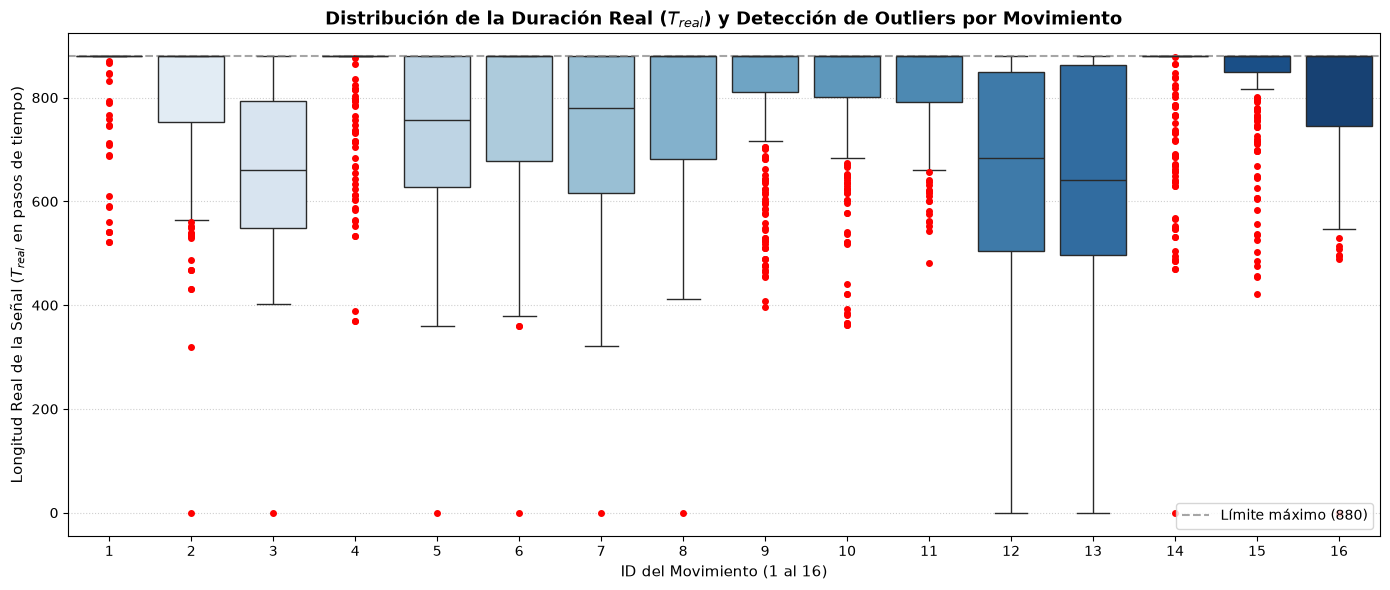

In [7]:
import numpy as np
import pandas as pd

reporte = []

for i in range(1, 17):
    s1 = eval(f"mov_{i}_1") # se obtiene el movimeinto del sensor 1
    s2 = eval(f"mov_{i}_2") # se obtiene el movimeinto del sensor 2
    N = s1.shape[0]

    for j in range(N): # Recorremos cada registro de movimiento
        fila_s1 = s1[j] 
        fila_s2 = s2[j]

        # Pasos activos, es decir, los pasos de tiempo donde al menos un canal tiene un valor distinto de cero
        pasos_activos1 = np.where(~np.all(fila_s1 == 0, axis=1))[0] 
        pasos_activos2 = np.where(~np.all(fila_s2 == 0, axis=1))[0]

        # t_real seria la longitud real de la señal, es decir, el último paso activo + 1 (es decir, antes de agregar el padding de ceros)
        if len(pasos_activos1) == 0 and len(pasos_activos2) == 0:
            # Si no hay pasos activos, entonces t_real es 0
            t_real = 0
        else:
            # Si hay pasos activos, t_real es el último paso activo + 1
            if len(pasos_activos1) == 0:
                t_real = pasos_activos2[-1] + 1
            elif len(pasos_activos2) == 0:
                t_real = pasos_activos1[-1] + 1
            else:
                t_real = max(pasos_activos1[-1], pasos_activos2[-1]) + 1
            
            

        # Varianza global del sensor (Suma de los 6 canales), utilizando solo los pasos activos
        val_s1 = fila_s1[:t_real]
        val_s2 = fila_s2[:t_real]
        
        
        if t_real > 0:
            # Calculamos la varianza de cada canal y luego sumamos las varianzas de los 6 canales
            var_total_s1 = np.sum(np.var(val_s1, axis=0))
            var_total_s2 = np.sum(np.var(val_s2, axis=0))
        else:
            var_total_s1 = 0.0
            var_total_s2 = 0.0

        # Determinamos si alguno de los sensores tiene una varianza total menor a un umbral muy pequeño (1e-8), lo que indicaría que el sensor está "muerto" o no está registrando movimiento.
        sensor_muerto = (var_total_s1 < 1e-8) or (var_total_s2 < 1e-8)
        
        # Guardamos un registro en el reporte con la información del movimiento, registro, duración real y si el sensor está muerto
        reporte.append(
            {
                "movimiento": i,
                "registro_id": j,
                "t_real": t_real,
                "varianza_s1": var_total_s1,
                "varianza_s2": var_total_s2,
                "canal_muerto": sensor_muerto,
            }
        )

df_rep = pd.DataFrame(reporte)

print("=== RESUMEN DE LIMPIEZA ===")
print(df_rep.groupby("movimiento").agg(
    total_registros=("registro_id", "count"),
    registros_descartados=("canal_muerto", "sum"),
    registros_validos=("canal_muerto", lambda x: (~x).sum()),
    porcentaje_descartados=("canal_muerto", lambda x: (x.sum() / x.count()) * 100),
    promedio_t_real=("t_real", "mean"),
    mediana_t_real=("t_real", "median"),
    min_t_real=("t_real", "min"),
    max_t_real=("t_real", "max"),
    std_t_real=("t_real", "std"),
).reset_index())

# Generamos un grafico de boxplot para visualizar la distribución de t_real por cada movimiento y detectar outliers
plt.figure(figsize=(14, 6))

# Graficar el boxplot de T_real para cada movimiento
ax = sns.boxplot(
    data=df_rep,
    x="movimiento",
    y="t_real",
    palette="Blues",
    fliersize=4,
    flierprops=dict(marker="o", markerfacecolor="red", markeredgecolor="red"),
)

plt.title(
    "Distribución de la Duración Real ($T_{real}$) y Detección de Outliers por Movimiento",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("ID del Movimiento (1 al 16)", fontsize=11)
plt.ylabel("Longitud Real de la Señal ($T_{real}$ en pasos de tiempo)", fontsize=11)
plt.axhline(
    880, color="gray", linestyle="--", alpha=0.7, label="Límite máximo (880)"
)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()


Atravez de esta grafica de caja y bigotes se puden observar los registros de cada movimiento y cuales serian sus outliners/ valores a limpiar. Sin embergo, si hicieramos la limpieza utilizando estos outliners como estan nos quedariamos con muy pocas muestras especialmente en el movimiento 1 y 4. Al estos tener muchos registros extremos, estos serian eliminados y al final nos quedariamos con pocas muestras para esos movimientos.

# Detectamos outliners con un IQR modificado para evitar elimiar registros de mas.

In [8]:

# 2. Detección de Outliers con IQR Modificado (Con Cota Inferior de Seguridad)
df_rep["outlier_iqr"] = False

for mov in df_rep["movimiento"].unique():
    mask_mov = df_rep["movimiento"] == mov
    sub = df_rep[mask_mov]

    # Calcular IQR solo sobre muestras con señal útil (t_real > 0)
    sub_validas = sub[sub["t_real"] > 0]
    
    # Se obtienen los cuartiles y el IQR para determinar los límites de outliers
    q1 = sub_validas["t_real"].quantile(0.25)
    q3 = sub_validas["t_real"].quantile(0.75)
    iqr = q3 - q1

    # Se calculan los limites inferior y superior usando la regla del IQR
    # Se ajusto la regla para que el limite inferior no sea tan alto cuando el IQR es cercano a cero, 
    # para evitar descartar muestras válidas.
    mediana = sub_validas["t_real"].median()
    lim_inferior_iqr = q1 - 1.5 * iqr
    lim_inferior_final = min(lim_inferior_iqr, mediana * 0.40) # Se establece que como mínimo acepte muestras de hasta el 40% de la mediana de esa clase

    # Marcar como outlier solo si t_real > 0 y cae por debajo del límite final
    es_outlier = (sub["t_real"] > 0) & (sub["t_real"] < lim_inferior_final)
    df_rep.loc[mask_mov & es_outlier, "outlier_iqr"] = True

# Combinamos los criterios de outlier por IQR y sensor muerto para determinar qué registros descartar
df_rep["descartar"] = df_rep["outlier_iqr"] | df_rep["canal_muerto"]

print("=== RESUMEN DE LIMPIEZA CON IQR ===")
print(f"Total registros analizados: {len(df_rep)}")
print(f"Registros a descartar por IQR: {df_rep['outlier_iqr'].sum()}")
print(f"Registros a descartar por sensor muerto: {df_rep['canal_muerto'].sum()}")
print(f"TOTAL DESCARTADOS: {df_rep['descartar'].sum()}")



=== RESUMEN DE LIMPIEZA CON IQR ===
Total registros analizados: 3900
Registros a descartar por IQR: 1
Registros a descartar por sensor muerto: 16
TOTAL DESCARTADOS: 17


# Se muetra graficamente los registros que serian eliminados para cada movimiento.

C:\Users\ngedg\AppData\Local\Temp\ipykernel_21052\3686013990.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


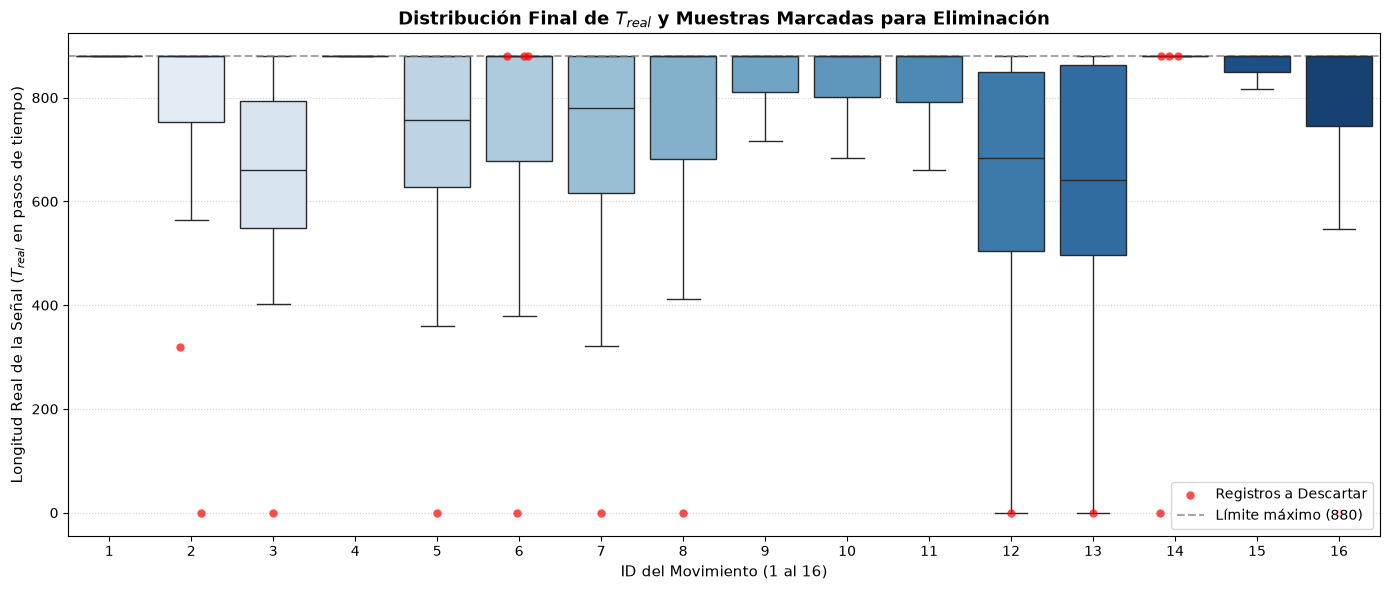

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# 1. Dibujar las cajas base ocultando outliers automáticos
ax = sns.boxplot(
    data=df_rep,
    x="movimiento",
    y="t_real",
    palette="Blues",
    showfliers=False,  # Ocultar la representación por defecto
)

# 2. Filtrar únicamente los registros marcados para descarte final
df_eliminados = df_rep[df_rep["descartar"] == True]

# 3. Superponer los registros a eliminar como puntos rojos
sns.stripplot(
    data=df_eliminados,
    x="movimiento",
    y="t_real",
    color="red",
    size=6,
    alpha=0.7,
    jitter=0.2,  # Dispersión leve para visualizar puntos superpuestos
    label="Registros a Descartar",
    ax=ax,
)

# Configuración visual y títulos
plt.title(
    "Distribución Final de $T_{real}$ y Muestras Marcadas para Eliminación",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("ID del Movimiento (1 al 16)", fontsize=11)
plt.ylabel(
    "Longitud Real de la Señal ($T_{real}$ en pasos de tiempo)", fontsize=11
)
plt.axhline(
    880, color="gray", linestyle="--", alpha=0.7, label="Límite máximo (880)"
)
plt.grid(axis="y", linestyle=":", alpha=0.6)

# Leyenda unificada sin duplicados
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc="lower right")

plt.tight_layout()
plt.show()

# Mostramos de forma grafica como se veria un reguistro correcto, uno por eliminar por IQR y uno por eliminar por sensor muerto

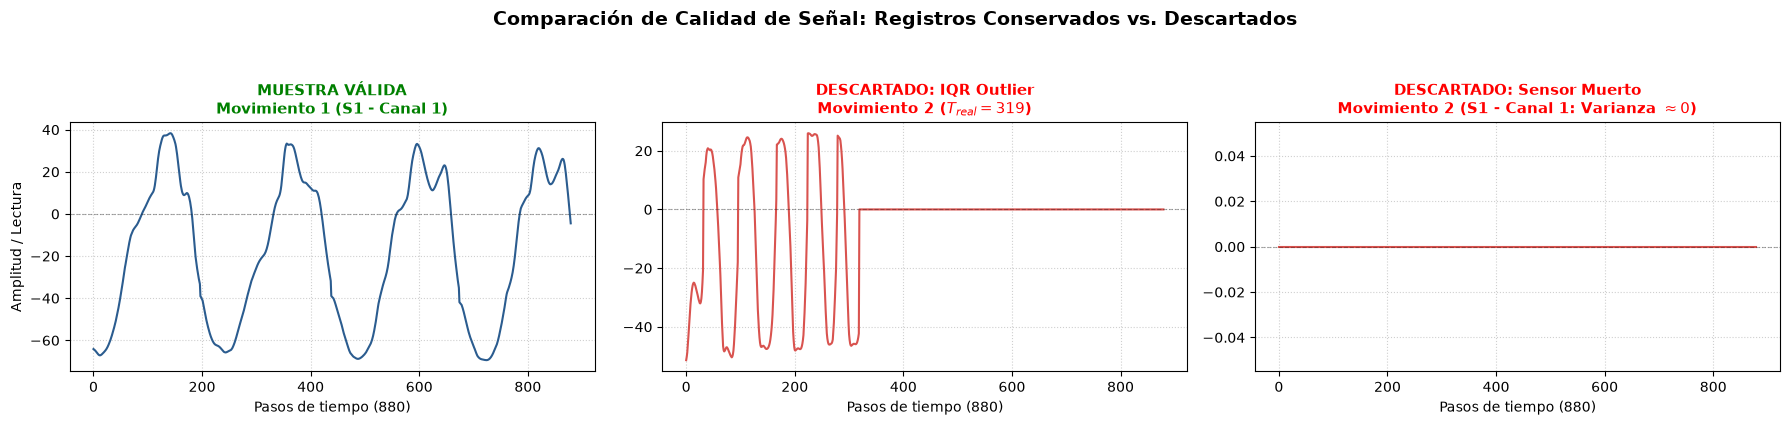

In [10]:

# 1. Muestra Válida
idx_valido = df_rep[df_rep["descartar"] == False].iloc[0]
s_valida = eval(f"mov_{idx_valido['movimiento']}_1")[
    idx_valido["registro_id"], :, 0
]

# 2. Descarte por IQR ajustado: Buscar el registro y el CANAL EXACTO que falló (var < 1e-6)
idx_outlier = df_rep[df_rep["outlier_iqr"] == True].iloc[0]
s_outlier = eval(f"mov_{idx_outlier['movimiento']}_1")[
    idx_outlier["registro_id"], :, 0
]

# 3. Descarte por Sensor Muerto: Buscar el registro y el CANAL EXACTO que falló (var < 1e-6)
registro_muerto_info = df_rep[df_rep["canal_muerto"] == True].iloc[0]
mov_m = registro_muerto_info["movimiento"]
reg_m = registro_muerto_info["registro_id"]

s1_m = eval(f"mov_{mov_m}_1")[reg_m]  # (880, 6)
s2_m = eval(f"mov_{mov_m}_2")[reg_m]  # (880, 6)

# Buscar cuál canal de los 12 presentó la varianza cero
canal_congelado = None
nombre_sensor = ""

# Evaluar canales de S1
for c in range(6):
    val = s1_m[: registro_muerto_info["t_real"], c]
    if len(val) == 0 or np.var(val) < 1e-6:
        canal_congelado = s1_m[:, c]
        nombre_sensor = f"S1 - Canal {c+1}"
        break

# Si no estaba en S1, buscar en S2
if canal_congelado is None:
    for c in range(6):
        val = s2_m[: registro_muerto_info["t_real"], c]
        if len(val) == 0 or np.var(val) < 1e-6:
            canal_congelado = s2_m[:, c]
            nombre_sensor = f"S2 - Canal {c+1}"
            break



fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)

# Muestra Válida
axes[0].plot(s_valida, color="#2b5c8f", linewidth=1.5)
axes[0].set_title(
    f"MUESTRA VÁLIDA\nMovimiento {idx_valido['movimiento']} (S1 - Canal 1)",
    fontsize=11,
    fontweight="bold",
    color="green",
)
axes[0].set_ylabel("Amplitud / Lectura")

# Descarte por Duración (IQR)
axes[1].plot(s_outlier, color="#d9534f", linewidth=1.5)
axes[1].set_title(
    f"DESCARTADO: IQR Outlier\nMovimiento {idx_outlier['movimiento']} ($T_{{real}}={idx_outlier['t_real']}$)",
    fontsize=11,
    fontweight="bold",
    color="red",
)

# Descarte por Sensor Muerto (Canal con falla real)
axes[2].plot(canal_congelado, color="#d9534f", linewidth=1.5)
axes[2].set_title(
    f"DESCARTADO: Sensor Muerto\nMovimiento {mov_m} ({nombre_sensor}: Varianza $\\approx 0$)",
    fontsize=11,
    fontweight="bold",
    color="red",
)

for ax in axes:
    ax.set_xlabel("Pasos de tiempo (880)")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.axhline(0, color="black", linestyle="--", alpha=0.3, linewidth=0.8)

plt.suptitle(
    "Comparación de Calidad de Señal: Registros Conservados vs. Descartados",
    fontsize=14,
    fontweight="bold",
    y=1.05,
)
plt.tight_layout()
plt.show()

# Mostramos el nuevo numero de muestras y la proorcion respecto a las muetras a eliminar.

=== REPORTE DE DESCARTES POR MOVIMIENTO ===
 movimiento  total_muestras  por_iqr  por_sensor_muerto  total_descartados  muestras_conservadas pct_descarte
          1             178        0                  0                  0                   178         0.0%
          2             193        1                  1                  2                   191        1.04%
          3             171        0                  1                  1                   170        0.58%
          4             200        0                  0                  0                   200         0.0%
          5             277        0                  1                  1                   276        0.36%
          6             282        0                  4                  4                   278        1.42%
          7             212        0                  1                  1                   211        0.47%
          8             383        0                  1                  1  

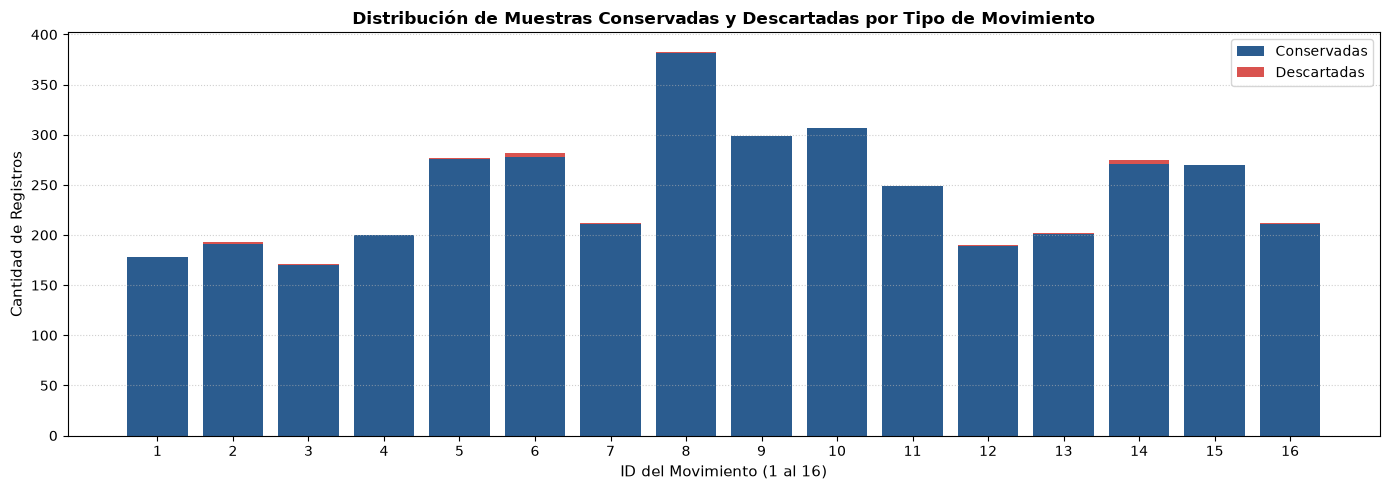

In [11]:
import pandas as pd

# 1. Agrupar descartes por movimiento y por tipo de falla
tabla_descartes = (
    df_rep.groupby("movimiento")
    .agg(
        total_muestras=("registro_id", "count"),
        por_iqr=("outlier_iqr", "sum"),
        por_sensor_muerto=("canal_muerto", "sum"),
        total_descartados=("descartar", "sum"),
    )
    .reset_index()
)

# 2. Calcular el porcentaje de descarte por clase y las muestras restantes
tabla_descartes["muestras_conservadas"] = (
    tabla_descartes["total_muestras"] - tabla_descartes["total_descartados"]
)
tabla_descartes["pct_descarte"] = (
    tabla_descartes["total_descartados"] / tabla_descartes["total_muestras"]
) * 100

# Formatear porcentaje para mejor lectura
tabla_descartes["pct_descarte"] = tabla_descartes["pct_descarte"].round(2).astype(str) + "%"

print("=== REPORTE DE DESCARTES POR MOVIMIENTO ===")
print(tabla_descartes.to_string(index=False))

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Graficar Muestras Conservadas vs Descartadas por Movimiento
plt.bar(
    tabla_descartes["movimiento"],
    tabla_descartes["muestras_conservadas"],
    color="#2b5c8f",
    label="Conservadas",
)
plt.bar(
    tabla_descartes["movimiento"],
    tabla_descartes["total_descartados"],
    bottom=tabla_descartes["muestras_conservadas"],
    color="#d9534f",
    label="Descartadas",
)

plt.title(
    "Distribución de Muestras Conservadas y Descartadas por Tipo de Movimiento",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("ID del Movimiento (1 al 16)", fontsize=11)
plt.ylabel("Cantidad de Registros", fontsize=11)
plt.xticks(tabla_descartes["movimiento"])
plt.legend(loc="upper right")
plt.grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

En este caso se puede observar que los registros a eliminar no son una cantidad significativa para nuestro data set, por lo tanto podemos proceder a eliminarlos.

# Realizamos el filtrado de los datos 

In [12]:
# Para cada movimiento, filtrar las muestras que no deben ser descartadas y actualizar las variables mov_i_1 y mov_i_2
for i in range(1, 17):
    mask_conservar = ~df_rep[df_rep["movimiento"] == i]["descartar"].values

    s1_clean = eval(f"mov_{i}_1")[mask_conservar] # Filtramos las muestras válidas del sensor 1
    s2_clean = eval(f"mov_{i}_2")[mask_conservar] # Filtramos las muestras válidas del sensor 2

    exec(f"mov_{i}_1 = s1_clean")
    exec(f"mov_{i}_2 = s2_clean")

# Imprimir la cantidad de muestras restantes después de la limpieza
for i in range(1, 17):
    s1_clean = eval(f"mov_{i}_1")
    s2_clean = eval(f"mov_{i}_2")
    print(f"Movimiento {i}: Sensor 1 - {s1_clean.shape[0]} muestras, Sensor 2 - {s2_clean.shape[0]} muestras")

Movimiento 1: Sensor 1 - 178 muestras, Sensor 2 - 178 muestras
Movimiento 2: Sensor 1 - 191 muestras, Sensor 2 - 191 muestras
Movimiento 3: Sensor 1 - 170 muestras, Sensor 2 - 170 muestras
Movimiento 4: Sensor 1 - 200 muestras, Sensor 2 - 200 muestras
Movimiento 5: Sensor 1 - 276 muestras, Sensor 2 - 276 muestras
Movimiento 6: Sensor 1 - 278 muestras, Sensor 2 - 278 muestras
Movimiento 7: Sensor 1 - 211 muestras, Sensor 2 - 211 muestras
Movimiento 8: Sensor 1 - 382 muestras, Sensor 2 - 382 muestras
Movimiento 9: Sensor 1 - 299 muestras, Sensor 2 - 299 muestras
Movimiento 10: Sensor 1 - 307 muestras, Sensor 2 - 307 muestras
Movimiento 11: Sensor 1 - 249 muestras, Sensor 2 - 249 muestras
Movimiento 12: Sensor 1 - 189 muestras, Sensor 2 - 189 muestras
Movimiento 13: Sensor 1 - 201 muestras, Sensor 2 - 201 muestras
Movimiento 14: Sensor 1 - 271 muestras, Sensor 2 - 271 muestras
Movimiento 15: Sensor 1 - 270 muestras, Sensor 2 - 270 muestras
Movimiento 16: Sensor 1 - 211 muestras, Sensor 2 

# Processo de transformacion

In [13]:
mov_1_combined = None
mov_2_combined = None
mov_3_combined = None
mov_4_combined = None
mov_5_combined = None
mov_6_combined = None
mov_7_combined = None
mov_8_combined = None
mov_9_combined = None
mov_10_combined = None
mov_11_combined = None
mov_12_combined = None
mov_13_combined = None
mov_14_combined = None
mov_15_combined = None
mov_16_combined = None

mov_combined_list = []
labels_list = []

# Unimos los canales de los sensores 1 y 2 para cada movimiento,
# resultando en un arreglo de forma (N, 880, 12)
for i in range(1, 17):

    s1_clean = eval(f"mov_{i}_1")  # (N, 880, 6)
    s2_clean = eval(f"mov_{i}_2")  # (N, 880, 6)

    # Concatenar los sensores a lo largo del eje de canales
    mov_combined = np.concatenate(
        (s1_clean, s2_clean),
        axis=2
    )  # (N, 880, 12)

    # Guardar cada movimiento combinado
    exec(f"mov_{i}_combined = mov_combined")

    print(
        f"Movimiento {i}: "
        f"{mov_combined.shape[0]} muestras de forma "
        f"({mov_combined.shape[1]}, {mov_combined.shape[2]})"
    )

    # Agregar las muestras del movimiento
    mov_combined_list.append(mov_combined)

    # Crear una etiqueta para cada muestra
    etiquetas_movimiento = np.full(
        mov_combined.shape[0],
        i
    )

    labels_list.append(etiquetas_movimiento)



# dataset final X con todas las muestras combinadas de los 16 movimientos
X = np.concatenate(
    mov_combined_list,
    axis=0
)


# etiquetas correspondientes a cada muestra
y = np.concatenate(
    labels_list,
    axis=0
)


print("\n--- DATASET FINAL ---")

print(
    f"X shape: {X.shape} "
    "(Total de muestras, 880 pasos de tiempo, 12 canales)"
)

print(
    f"y shape: {y.shape} "
    "(Etiqueta correspondiente a cada muestra)"
)

# Ver el numero de etiquetas únicas y su distribución
unique, counts = np.unique(y, return_counts=True)

print(f"Etiquetas únicas: {unique}")
print(f"Distribución: {counts}")


Movimiento 1: 178 muestras de forma (880, 12)
Movimiento 2: 191 muestras de forma (880, 12)
Movimiento 3: 170 muestras de forma (880, 12)
Movimiento 4: 200 muestras de forma (880, 12)
Movimiento 5: 276 muestras de forma (880, 12)
Movimiento 6: 278 muestras de forma (880, 12)
Movimiento 7: 211 muestras de forma (880, 12)
Movimiento 8: 382 muestras de forma (880, 12)
Movimiento 9: 299 muestras de forma (880, 12)
Movimiento 10: 307 muestras de forma (880, 12)
Movimiento 11: 249 muestras de forma (880, 12)
Movimiento 12: 189 muestras de forma (880, 12)
Movimiento 13: 201 muestras de forma (880, 12)
Movimiento 14: 271 muestras de forma (880, 12)
Movimiento 15: 270 muestras de forma (880, 12)
Movimiento 16: 211 muestras de forma (880, 12)

--- DATASET FINAL ---
X shape: (3883, 880, 12) (Total de muestras, 880 pasos de tiempo, 12 canales)
y shape: (3883,) (Etiqueta correspondiente a cada muestra)
Etiquetas únicas: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Distribución: [178 191 170 20

Se concatenaron los canales de ambos sensores en su respectivo registro, esto se debe a que si queremos predecir el tipo de movimiento de acuerdo a sus datos el unir los canales nos ayuda a tener todos los datos en la misma estructura. A su vez, se determino mantener las 880 puntos en cada muestra.

Tras unir los canales, se genero el dataset final al unir todas las muestras de todos los movimientos, mientas que tambien se guarda registro de las etiquetas de cada registro.

# Obtenermos estadisticos basicos de cada canal 

In [14]:
estadisticas = []
# Obtenemos la longitud real de la señal para la muestra actual
t_real_all = df_rep.loc[df_rep["descartar"] == False, "t_real"].values

print(f"Total de muestras válidas: {len(t_real_all)}")


for canal in range(X.shape[2]):
    valores_reales = []

    for muestra in range(X.shape[0]):
        longitud = t_real_all[muestra]

        señal = X[muestra, :longitud, canal]

        valores_reales.extend(señal)

    valores_reales = np.array(valores_reales)

    estadisticas.append({
        "Canal": canal,
        "Min": np.min(valores_reales),
        "Max": np.max(valores_reales),
        "Media": np.mean(valores_reales),
        "Mediana": np.median(valores_reales),
        "Std": np.std(valores_reales),
        "Varianza": np.var(valores_reales),
        "P25": np.percentile(valores_reales, 25),
        "P75": np.percentile(valores_reales, 75),
        "Rango": np.max(valores_reales) - np.min(valores_reales)
    })

df_stats = pd.DataFrame(estadisticas)

display(df_stats)
    

Total de muestras válidas: 3883


,Canal,Min,Max,Media,Mediana,Std,Varianza,P25,P75,Rango
0,0,-89.618000,89.71400,5.897542,0.000000,38.656503,1494.325217,-19.370000,30.600000,179.332000
1,1,-1158.667000,367.22200,-2.202516,0.000000,44.931481,2018.837996,-10.112000,9.026000,1525.889000
2,2,-1178.349000,375.15600,-6.198316,-0.287000,48.089033,2312.555100,-18.814000,8.211000,1553.505000
3,3,-89.418000,89.62600,24.244725,31.764000,40.129217,1610.354084,0.000000,56.973000,179.044000
4,4,-683.630000,887.39300,0.378781,0.000000,28.877545,833.912613,-4.434000,4.801000,1571.023000
5,5,-497.796000,985.47400,-0.245708,0.000000,22.490666,505.830075,-4.328000,3.950000,1483.270000
6,6,0.000000,117.00000,31.811898,23.000000,23.078879,532.634637,22.000000,31.000000,117.000000
7,7,0.000000,114.00000,33.693838,26.000000,23.378045,546.532983,20.000000,39.000000,114.000000
8,8,0.000000,114.00000,33.368200,27.000000,20.301164,412.137256,22.000000,38.000000,114.000000
9,9,0.000000,113.00000,33.609348,26.000000,21.291916,453.345687,22.000000,38.000000,113.000000


Al checar los estadisticos de cada canal sin considerar los 0, se puede observar que hay una gran diferencia entre los estadisticos respecto a su rango y desviacion estandar. Por esto mismo, se debe de realizar una estandarizacion de los canales para evitar que ciertos canales tengan mas valor que otros.

# Separacion en test y train sets

In [15]:
from sklearn.model_selection import train_test_split

# Dividimos el dataset en conjunto de entrenamiento y prueba, asegurando que la distribución de clases se mantenga 
# También separamos la longitud real de la señal (t_real) para cada muestra.
X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X,
    y,
    t_real_all,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Normalizacion de los datos usando StandardScaler

In [16]:
from sklearn.preprocessing import StandardScaler

# Calcula la media y la desviación estándar únicamente en el conjunto de entrenamiento
num_canales = X_train.shape[2]
medias_train = np.zeros(num_canales)
stds_train = np.zeros(num_canales)

for canal in range(num_canales):
    valores_reales = []
    for muestra in range(X_train.shape[0]):
        longitud = t_train[muestra]
        señal = X_train[muestra, :longitud, canal]
        valores_reales.extend(señal)
    
    valores_reales = np.array(valores_reales)
    medias_train[canal] = np.mean(valores_reales)
    stds_train[canal] = np.std(valores_reales)

# Creamos un objeto StandardScaler y le asignamos la media y desviación estándar calculadas
scaler = StandardScaler()
scaler.mean_ = medias_train
scaler.scale_ = stds_train
scaler.var_ = stds_train ** 2


Calculamos los estadisticos de media y de desviacion estandar de los canales del conjunto de entrenamiento considerando el padding. Se inicializa el scalador de StandardScaler utilizando estos valores.

In [17]:

# Funcion para transformar los datos con padding, aplicando el escalado solo a la porción de la señal que contiene datos reales
def transformar_con_padding(X_data, t_real_data, scaler_fit):
    X_scaled = X_data.copy().astype(float)
    for muestra in range(X_data.shape[0]):
        longitud = t_real_data[muestra]
        # Escalamos únicamente la porción con señal real
        X_scaled[muestra, :longitud, :] = scaler_fit.transform(X_data[muestra, :longitud, :])
        # El resto (de 'longitud' en adelante) se mantiene como 0 (padding)
    return X_scaled

X_train_norm = transformar_con_padding(X_train, t_train, scaler)
X_test_norm = transformar_con_padding(X_test, t_test, scaler)

# Mostramos los nuevos estadisticos de los datos normalizados

In [18]:
# Mostramos los estadisticos de los datos normalizados para verificar que la media sea cercana a 0 y la desviación estándar cercana a 1
estadisticas_norm = []

for canal in range(X_train_norm.shape[2]):
    valores_reales = []
    for muestra in range(X_train_norm.shape[0]):
        longitud = t_train[muestra]
        señal = X_train_norm[muestra, :longitud, canal]
        valores_reales.extend(señal)
    
    valores_reales = np.array(valores_reales)

    estadisticas_norm.append({
        "Canal": canal,
        "Min": np.min(valores_reales),
        "Max": np.max(valores_reales),
        "Media": np.mean(valores_reales),
        "Mediana": np.median(valores_reales),
        "Std": np.std(valores_reales),
        "Varianza": np.var(valores_reales),
        "P25": np.percentile(valores_reales, 25),
        "P75": np.percentile(valores_reales, 75),
        "Rango": np.max(valores_reales) - np.min(valores_reales)
    })

df_stats_norm = pd.DataFrame(estadisticas_norm)
display(df_stats_norm)



,Canal,Min,Max,Media,Mediana,Std,Varianza,P25,P75,Rango
0,0,-2.468267,2.161651,1.217802e-17,-0.152224,1.0,1.0,-0.650658,0.635471,4.629917
1,1,-25.689280,8.206006,1.049183e-17,0.048732,1.0,1.0,-0.177801,0.249298,33.895286
2,2,-24.354986,7.853538,4.871206e-18,0.123035,1.0,1.0,-0.269094,0.300711,32.208524
3,3,-2.832979,1.626911,-2.098366e-17,0.184105,1.0,1.0,-0.605625,0.812670,4.459890
4,4,-23.643031,30.657028,-1.498833e-18,-0.014383,1.0,1.0,-0.169020,0.155428,54.300059
5,5,-21.862673,43.316802,-3.747082e-18,0.012024,1.0,1.0,-0.177283,0.190301,65.179475
6,6,-1.375604,3.709659,-1.423891e-17,-0.375937,1.0,1.0,-0.419401,-0.028227,5.085263
7,7,-1.438444,3.417948,1.468856e-16,-0.330846,1.0,1.0,-0.543846,0.222953,4.856393
8,8,-1.650356,4.008445,-1.386420e-17,-0.310114,1.0,1.0,-0.558307,0.235911,5.658801
9,9,-1.578960,3.733878,3.597199e-17,-0.356538,1.0,1.0,-0.544603,0.207658,5.312838


# Correlacion entre las variables mapa de calor

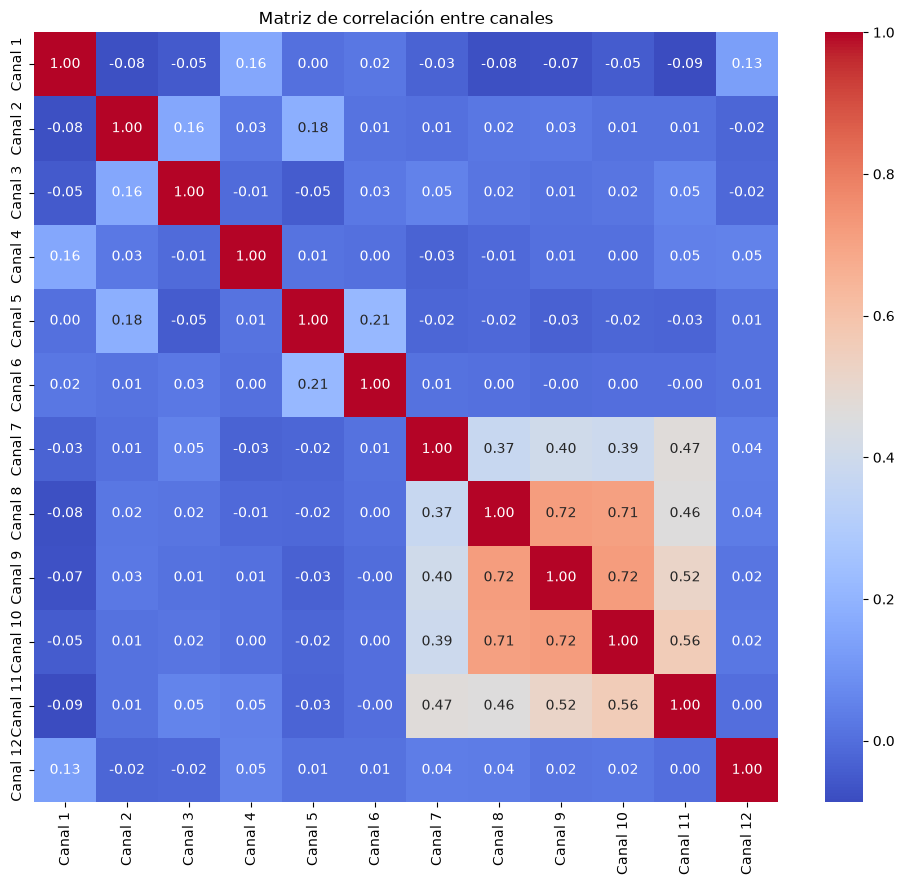

In [19]:
# Correlacion entre los canales de los sensores 1 y 2 con los datos normalizados, considerando solo la porción de la señal que contiene datos reales (sin padding)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Número de canales
num_canales = X_train_norm.shape[2]

# Matriz: canales + variable objetivo
correlacion = np.zeros((num_canales + 1, num_canales + 1))

# Guardaremos todos los valores de cada canal
valores_canales = [[] for _ in range(num_canales)]


# Recorremos cada muestra
for muestra in range(X_train_norm.shape[0]):
    
    longitud = t_train[muestra]
    
    if longitud > 0:
        
        # Agregamos los valores de cada canal
        for canal in range(num_canales):
            valores_canales[canal].extend(
                X_train_norm[muestra, :longitud, canal]
            )

# Convertimos todo a arreglos de NumPy
valores_canales = [
    np.array(valores) for valores in valores_canales
]

# Creamos una matriz con todos los canales + variable objetivo
datos_correlacion = np.column_stack(
    valores_canales
)

# Calculamos la correlación
correlacion = np.corrcoef(
    datos_correlacion,
    rowvar=False
)

# Etiquetas
etiquetas = (
    [f"Canal {i+1}" for i in range(num_canales)]
)

# Visualizamos la matriz
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels=etiquetas,
    yticklabels=etiquetas
)

plt.title("Matriz de correlación entre canales")
plt.show()

In [20]:
import numpy as np

def promediar_canales_sensor2(X_norm):
    """
    Toma las 12 columnas de canal, calcula la media de los canales 8, 9 y 10,
    y sustituye esas tres columnas por un único canal promedio.
    Pasa de (N, 880, 12) a (N, 880, 10).
    """
    # 1. Extraer los canales 8, 9 y 10 -> Forma: (N, 880, 3)
    canales_sensor2 = X_norm[:, :, [8, 9, 10]]
    
    # 2. Calcular el promedio entre esos tres canales -> Forma: (N, 880, 1)
    canal_promedio = np.mean(canales_sensor2, axis=2, keepdims=True)
    
    # 3. Eliminar los canales originales 8, 9 y 10 -> Quedan 9 canales
    X_sin_sensor2 = np.delete(X_norm, [8, 9, 10], axis=2)
    
    # 4. Concatenar el nuevo canal promedio con el resto de canales -> Quedan 10 canales
    X_reducido = np.concatenate([X_sin_sensor2, canal_promedio], axis=2)
    
    return X_reducido

# Aplicar la transformación a Train y Test
X_train_reducido = promediar_canales_sensor2(X_train_norm)
X_test_reducido = promediar_canales_sensor2(X_test_norm)

print(f"Forma original Train: {X_train_norm.shape}")
print(f"Forma reducida Train: {X_train_reducido.shape}")  # (3106, 880, 10)

X_train_norm = X_train_reducido
X_test_norm = X_test_reducido

Forma original Train: (3106, 880, 12)
Forma reducida Train: (3106, 880, 10)


# Creacion de modelo de ML

Division de timeline en distintas ventanas, se guarda media, std, min, max, rms

In [21]:
import numpy as np

def extraer_caracteristicas_por_canal(X_norm, window_size=80):
    """
    Transforma (N, 880, 12) -> (N, 12 * num_features * num_ventanas)
    recorriendo explícitamente cada canal y cada ventana temporal.
    """
    N, T, C = X_norm.shape
    num_windows = T // window_size  # 880 // 80 = 11
    
    X_features = []
    
    for i in range(N):
        muestra_features = []
        
        # Recorrido explícito canal por canal (12 canales)
        for canal in range(C):
            for w in range(num_windows):
                inicio = w * window_size
                fin = inicio + window_size
                
                # Segmento de 80 pasos para el canal actual
                segmento = X_norm[i, inicio:fin, canal]
                
                # Manejo de padding (si toda la ventana en el canal es 0)
                if np.all(segmento == 0):
                    feat_mean = 0.0
                    feat_std = 0.0
                    feat_max = 0.0
                    feat_min = 0.0
                    feat_rms = 0.0
                else:
                    feat_mean = np.mean(segmento)
                    feat_std = np.std(segmento)
                    feat_max = np.max(segmento)
                    feat_min = np.min(segmento)
                    feat_rms = np.sqrt(np.mean(segmento**2))
                
                # Agregar las 5 características de este canal y ventana
                muestra_features.extend([feat_mean, feat_std, feat_max, feat_min, feat_rms])
                
        X_features.append(muestra_features)
        
    return np.array(X_features)

# Aplicar sobre los datos normalizados
X_train_feat = extraer_caracteristicas_por_canal(X_train_norm, window_size=80)
X_test_feat = extraer_caracteristicas_por_canal(X_test_norm, window_size=80)

print(f"Forma original Train: {X_train_norm.shape}")
print(f"Forma ajustada Train:  {X_train_feat.shape}")  # (3106, 660)
print(f"Forma ajustada Test:   {X_test_feat.shape}")

Forma original Train: (3106, 880, 10)
Forma ajustada Train:  (3106, 550)
Forma ajustada Test:   (777, 550)


# Nearest Centroid Algorithm
Generates the centroids for all the movements, there are 16 movements.

In [22]:
import numpy as np

# Obtener las clases únicas reales
clases_unicas = np.unique(y_train)
num_classes = len(clases_unicas)
num_features = X_train_feat.shape[1]

print(f"Numero de clases: {num_classes}")
print(f"Forma de los datos de entrenamiento: {X_train_feat.shape}")

centroides = np.zeros((num_classes, num_features))

# Entrenar (obtenemos los centroides de cada clase)
for c_idx, clase_val in enumerate(clases_unicas):
    # Filtrar muestras pertenecientes a la clase actual
    indices_clase_c = np.where(y_train == clase_val)[0]
    muestras_clase_c = X_train_feat[indices_clase_c]
    
    conteo_muestras_clase = len(muestras_clase_c)
    suma_caracteristicas = np.zeros(num_features)
    
    # Sumatoria manual por característica
    for i in range(conteo_muestras_clase):
        for j in range(num_features):
            suma_caracteristicas[j] += muestras_clase_c[i, j]
    
    # Promedio por característica
    centroide_c = suma_caracteristicas / conteo_muestras_clase
    centroides[c_idx] = centroide_c  



print(f"Centroides forma: {centroides.shape}")

Numero de clases: 16
Forma de los datos de entrenamiento: (3106, 550)
Centroides forma: (16, 550)


We predict for every data of the test partition

In [23]:
aciertos = 0
aciertos_clase = np.zeros(num_classes)

for i, x in enumerate(X_test_feat):
    # Distancia euclidiana a cada centroide, reduciendo su peso conforme mas cerca este del final del vector de características
    distancias = np.linalg.norm(centroides - x, axis=1)
    
    # Mapear el centroide más cercano a la etiqueta correspondiente
    idx_centroide_cercano = np.argmin(distancias)
    clase_predicha = clases_unicas[idx_centroide_cercano]
    
    # Acceso directo a la clase real mediante el índice i
    clase_real = y_test[i]
    
    if clase_predicha == clase_real:
        aciertos += 1
        aciertos_clase[idx_centroide_cercano] += 1

print(f" Clase predicha: {clase_predicha}, Clase real: {clase_real}")

accuracy = aciertos / len(X_test_feat)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

print(f"Aciertos por clase: {aciertos_clase}")
# accuracy por clase
accuracy_por_clase = aciertos_clase / np.array([np.sum(y_test == clase) for clase in clases_unicas])
print(f"Accuracy por clase: {accuracy_por_clase * 100}")

 Clase predicha: 16, Clase real: 16

Accuracy: 58.04%
Aciertos por clase: [27. 32. 21. 27. 37. 33. 23. 58. 36. 27. 22. 20.  7. 24. 27. 30.]
Accuracy por clase: [75.         84.21052632 61.76470588 67.5        67.27272727 58.92857143
 54.76190476 75.32467532 60.         44.26229508 44.         52.63157895
 17.5        44.44444444 50.         71.42857143]
